In [94]:
import casadi as cs
import numpy as np
import pickle
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from MPC.baseline import Solver as Baseline
from MPC.solver_2steps import Solver
from MPC.solver_1step import Solver as Solver_1
from time import time

In [95]:
def reorder(branch):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 0.02:
            idx = i+1
    fixed_traj = np.vstack([np.flip(traj[:idx,:],axis=0),traj[idx:,:]])
    if traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        fixed_traj[:,[0,2,3,5]] = - fixed_traj[:,[0,2,3,5]]
    return fixed_traj

def separate(traj):
    idx = 0
    for i in range(100,traj.shape[0] -101):
        de1 = traj[i,-1] - traj[i-1,-1]
        de2 = traj[i+1,-1] - traj[i,-1]
        if de1*de2 < 0:
            idx = i + 1
    return traj[:idx,:],traj[idx:,:]

def flip(traj):
    flipped_traj = np.zeros(traj.shape)
    for i in range(traj.shape[0]):
        flipped_traj[i] = traj[traj.shape[0]-1-i]
    return flipped_traj


def getLUT(NMM):
    N_SAMPLES = 100
    skip = max(1,int(NMM.shape[0]/N_SAMPLES))
    NMM_sampled = NMM[10:-10:skip,:]
    E_grid = NMM_sampled[:,-1]
    values = NMM_sampled.ravel(order="C")
    LUT = cs.interpolant('LUT', 'bspline',[E_grid],values)
    return LUT,E_grid[0],E_grid[-1]

def get_trajectory(solver,u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = solver.traj_f_list(x0, dt[0], xi)
    traj2 = solver.stance_to_flight(
        solver.traj_s_list(solver.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = solver.traj_f_list(traj2[:, -1], dt[2], xi)
    traj4 = solver.traj_f_list(traj3[:,-1], dt[0], xi)
    traj = cs.horzcat(traj2, traj2[:,-1], traj3[:,:-1], traj4)
    return np.array(traj)



Load data from disk. The dataset is a dicitionary with keys:
* `K` dimensionless stiffness
* `W` dimensionless leg frequency
* `locomotion` list of all connected forward/backward locomotion NMMs
* `switch` list of all connected switch NMMs
* `step_size` step size of the continuation method

In [96]:
data = pickle.load(open('data/dataset_4.pkl','rb'))
K = data["K"]
W = data["W"]

Pre-processing of the data to get coorectly defined generators: Each generator is a collection of fixed points in the apex Poincare section. Each generator is parametrized by the energy level. The energy is *striclty* increasing along each branch. 

In [97]:
FW = reorder(data["locomotion"][2])
FW_TO_BW = np.flip(reorder(data["switch"][2]),axis = 0)
FW1,FW2 = separate(FW)
FW = FW1 if FW1.shape[0] > FW2.shape[0] else FW2
BW = FW.copy()
BW[:,[0,2,3,5]] = - FW[:,[0,2,3,5]]
BW_TO_FW = FW_TO_BW.copy()
BW_TO_FW[:,[0,2,3,5]] = - FW_TO_BW[:,[0,2,3,5]]

Create a multi-dimensional b-spline look-up-table of the chosen NMMs. 
* `FW` is forward motion
* `BW` is backward motion
* `FW_TO_BW` is forward to backward motion
* `BW_TO_FW` is backward to forward motion

In [98]:
LUT_FW,Emin_FW,Emax_FW = getLUT(FW)
LUT_BW,Emin_BW,Emax_BW = getLUT(BW)
LUT_FW_TO_BW,Emin_FW_TO_BW,Emax_FW_TO_BW = getLUT(FW_TO_BW)
LUT_BW_TO_FW,Emin_BW_TO_FW,Emax_BW_TO_FW = getLUT(BW_TO_FW)

Chose the desired energy level and build the solvers. 

In [99]:
E_star = 4
Emin, Emax = E_star - 0.5, E_star + 0.5

S_rev_2s = Solver(50,K,W,max(Emin,Emin_BW_TO_FW),min(Emax_BW_TO_FW,Emax),LUT_BW_TO_FW,True)
S_bac_2s = Solver(50,K,W,max(Emin,Emin_BW),min(Emax_BW,Emax),LUT_BW,False)
S_rev_1s = Solver_1(50,K,W,max(Emin,Emin_BW_TO_FW),min(Emax_BW_TO_FW,Emax),LUT_FW_TO_BW,True)
S_bac_1s = Solver_1(50,K,W,max(Emin_BW,Emin),min(Emax_BW,Emax),LUT_BW,False)
solver_B = Solver(50,K,W,max(Emin_BW,Emin),min(Emax_BW,Emax),LUT_BW,False)

Build reference trajectories by integrating forward from the generators.

In [100]:
u_fw = LUT_FW(E_star)
u_bw = LUT_BW(E_star)
u_fw_to_bw = LUT_FW_TO_BW(E_star)
u_bw_to_fw = LUT_BW_TO_FW(E_star)
fw = get_trajectory(S_bac_2s,u_fw)
bw = get_trajectory(S_bac_2s,u_bw)
fw_to_bw = get_trajectory(S_bac_2s,u_fw_to_bw)
bw_to_fw = get_trajectory(S_bac_2s,u_bw_to_fw)


In [101]:
## first step with

x0 = fw[[0,1,3,4],0]
xs_init = fw[[0,1,3,4],:S_rev_2s.N]
xf_init = fw[:,S_rev_2s.N:]
dt_init = cs.vertcat(u_fw[7],u_fw[6]+u_fw[8])
S_rev_1s.initialize(x0,xs_init,xf_init,dt_init,0,0)
start = time()
sol_rev_1s = S_rev_1s.solve()
end = time()
print(end-start)
print(sol_rev_1s["step_size"],dt_init)
print(S_rev_1s.opti.value(S_rev_1s.rt))

passive_traj = S_rev_1s.traj_s_list(S_rev_1s.flight_to_stance(sol_rev_1s['flight'][:,-1]),u_bw[7],0)


0.16915225982666016
[0.00917656 0.06139454] [0.00906165, 0.125664]
[ 0.00600766  0.00119591 -0.0079049 ]


In [102]:
# # second step

x0 = S_rev_1s.flight_to_stance(sol_rev_1s["flight"][:,-1])
xs_init = fw_to_bw[[0,1,3,4],:S_rev_2s.N]
xf_init = fw_to_bw[:,S_rev_2s.N:]
dt_init = cs.vertcat(u_fw_to_bw[7],u_fw_to_bw[6]+u_fw_to_bw[8])
S_bac_1s.initialize(x0,xs_init,xf_init,dt_init)
start = time()
sol_bac_1s = S_bac_1s.solve()
end = time()
print(end-start)
e = 0.5*(sol_bac_1s['flight'][3,-1]**2+sol_bac_1s['flight'][4,-1]**2) + sol_bac_1s['flight'][1,-1]**2
u_end = LUT_BW(e)
passive_traj_ = S_bac_1s.traj_f_list(u_end[:6],u_bw[6],0)
passive_trajs = S_bac_1s.stance_to_flight(S_bac_1s.traj_s_list(S_bac_1s.flight_to_stance(passive_traj_[:,-1]),u_end[7],0))
passive_trajf = S_bac_1s.traj_f_list(passive_trajs[:,-1],u_bw[6]*2,0)

0.1458141803741455


In [103]:
# baseline 
x0 = fw[[0,1,3,4],0]
xs_init = [fw[[0,1,3,4],:S_rev_2s.N],fw_to_bw[[0,1,3,4],:S_rev_2s.N]]
xf_init = [fw[:,S_rev_2s.N:],fw_to_bw[:,S_rev_2s.N:]]
dt_init = cs.vertcat(u_fw[6]+u_fw[8],u_fw[7],u_fw[6]+u_fw[8],u_fw[7])
solver_B.initialize(x0,xs_init,xf_init,dt_init)
start = time()
sol_baseline = solver_B.solve()
end = time()
print(end-start)
passive_baselines = S_bac_1s.stance_to_flight(S_bac_1s.traj_s_list(S_bac_1s.flight_to_stance(sol_baseline['flight'][1][:,-1]),u_bw[7],0))
passive_baselinef = S_bac_1s.traj_f_list(passive_baselines[:,-1],u_bw[6]*2,0)

0.8063898086547852


In [104]:
traj = [
    np.array(fw),
    np.array(S_bac_1s.stance_to_flight(sol_rev_1s['stance'])),
    np.array(sol_rev_1s['flight']),
    np.array(S_bac_1s.stance_to_flight(sol_bac_1s['stance'])),
    np.array(sol_bac_1s['flight']),
    np.array(passive_trajs),
    np.array(passive_trajf)
]

for i in range(1,7):
    traj[i][0,:] += traj[i-1][0,-1] - traj[i][0,0]
traj = np.hstack(traj)

traj_baseline = [
    np.array(fw),
    np.array(S_bac_1s.stance_to_flight(sol_baseline["stance"][0])),
    np.array(sol_baseline["flight"][0]),
    np.array(S_bac_1s.stance_to_flight((sol_baseline["stance"][1]))),
    np.array(sol_baseline["flight"][1]),
    np.array(passive_baselines),
    np.array(passive_baselinef)
]

for i in range(1,7):
    traj_baseline[i][0,:] += traj_baseline[i-1][0,-1] - traj_baseline[i][0,0]
traj_baseline = np.hstack(traj_baseline)


In [173]:
from matplotlib import colorbar,colors,colorizer,cm

def get_surface(N,data,solver,loop=True):
    surface = np.zeros((N,6,2*solver.N + loop))
    fcolor = np.zeros((N,2*solver.N + loop))
    for i in range(N):
        surface[i,:,:] = get_traj(solver,data[int(i*data.shape[0]/N)],loop)
        fcolor[i,:] = data[int(i*data.shape[0]/N)][-1]
    return surface,fcolor

def get_traj(solver,u, loop=True):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = solver.traj_f_list(x0, dt[0], xi)
    traj2 = solver.stance_to_flight(
        solver.traj_s_list(solver.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = solver.traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    if loop:
        traj = cs.horzcat(traj1, traj2, traj3, traj1[:,0])
    else:
        traj1_ = traj1
        traj1_[[0,2,3,5],:] = -traj1[[0,2,3,5],:]
        traj = cs.horzcat(traj2, traj3,traj1_)
    return np.array(traj)



surface_FW,faces_FW = get_surface(100,FW[:400,:],S_bac_1s)
norm_FW = colors.Normalize(vmin=faces_FW.min(), vmax=faces_FW.max())
fcolor_FW = cm.cool(norm_FW(faces_FW))[:-1, :-1]


surface_BW,faces_BW = get_surface(100,BW[:400,:],S_bac_1s)
norm_BW = colors.Normalize(vmin=faces_BW.min(), vmax=faces_BW.max())
fcolor_BW = cm.cool(norm_FW(faces_BW))[:-1, :-1]


surface_FW_TO_BW,faces_FW_TO_BW = get_surface(10,FW_TO_BW[100:400,:],S_bac_1s,False)
norm_FW_TO_BW = colors.Normalize(vmin=faces_FW_TO_BW.min(), vmax=faces_FW_TO_BW.max())
fcolor_FW_TO_BW = cm.cool(norm_FW_TO_BW(faces_FW_TO_BW))[:-1, :-1]

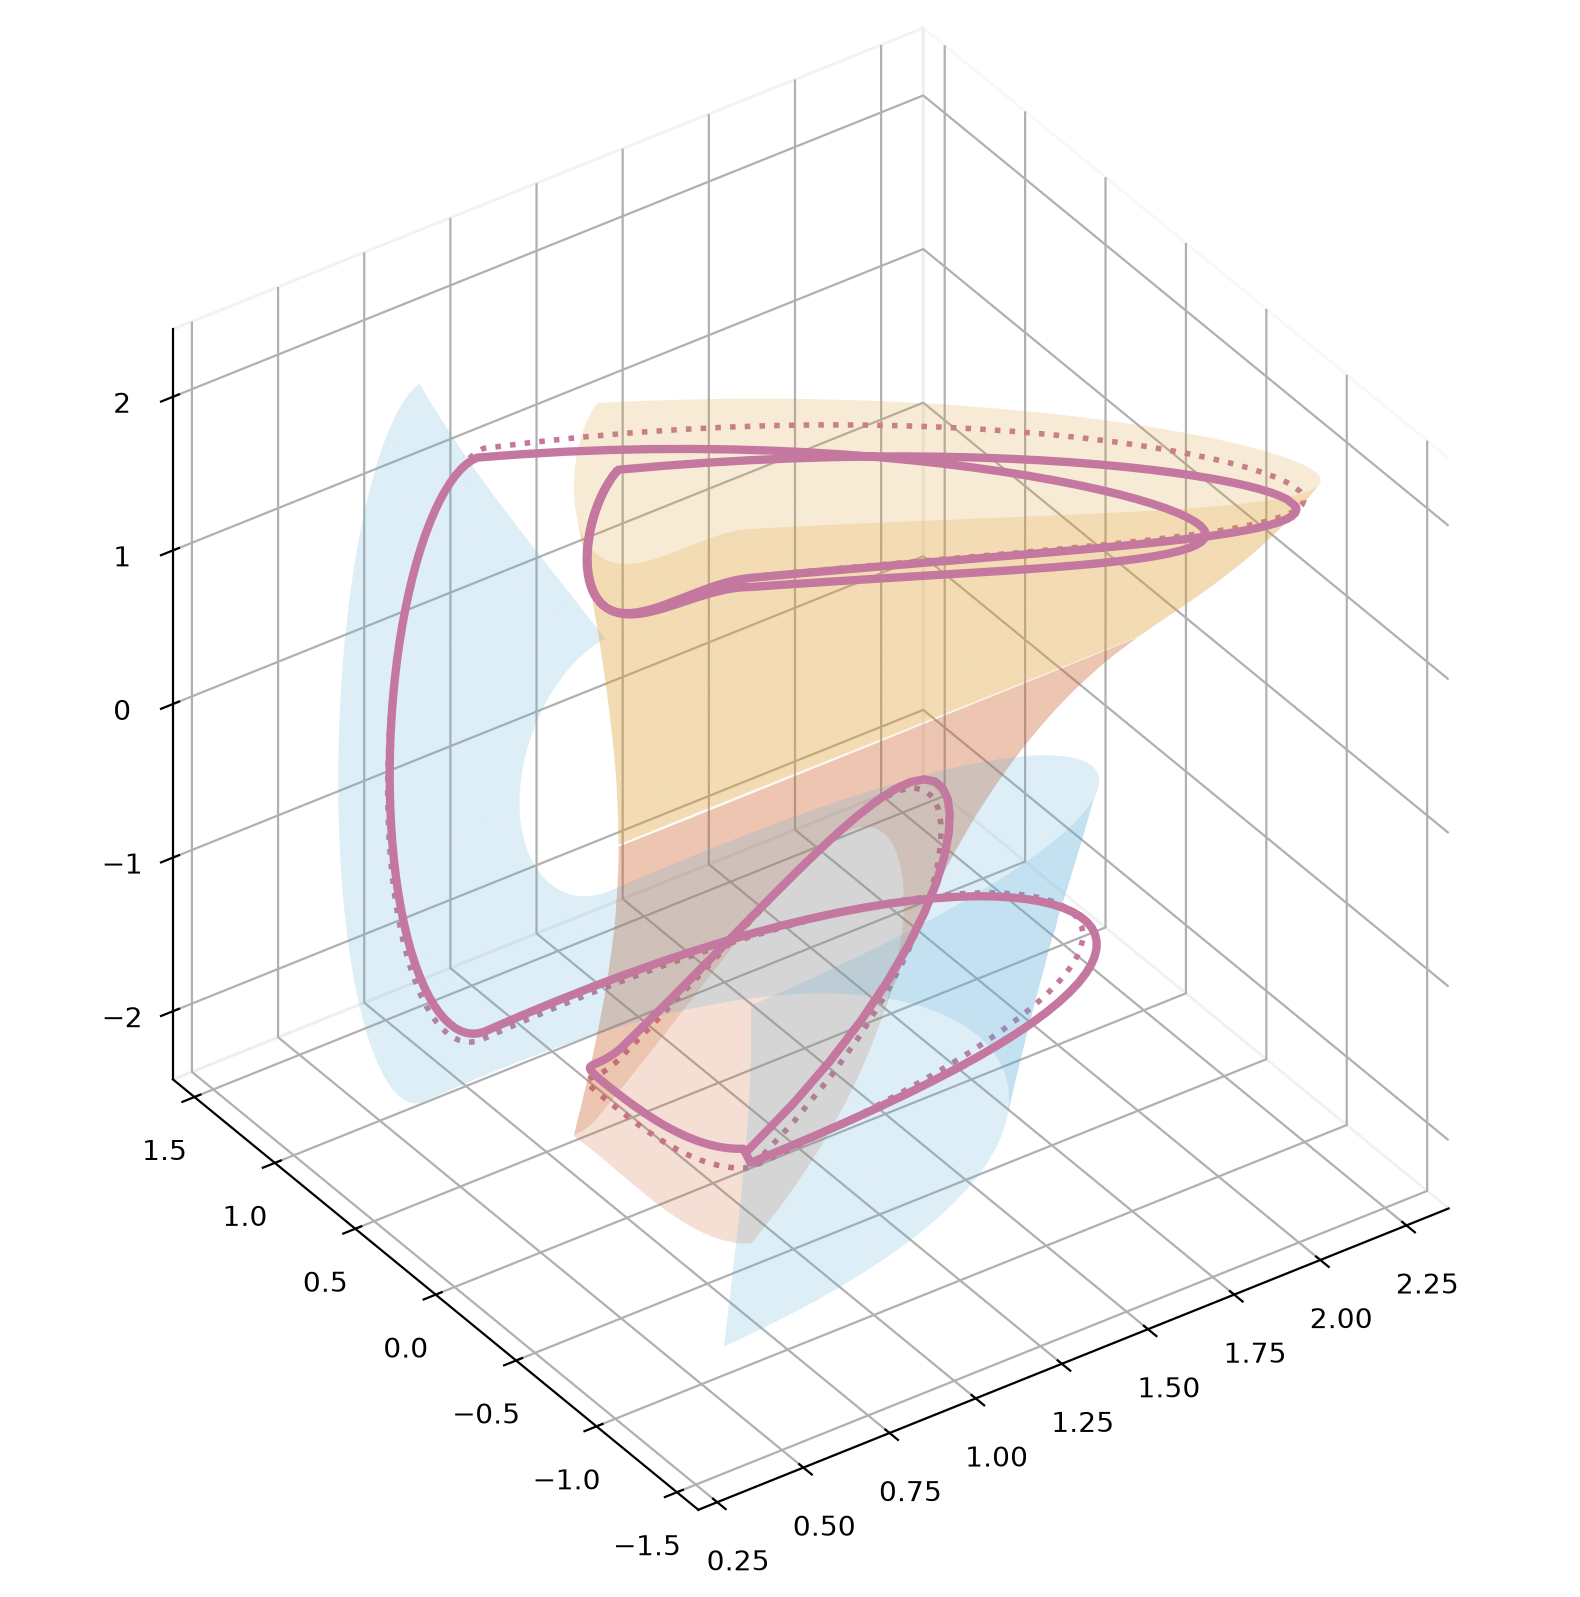

In [179]:

fig = plt.figure(figsize=(10,10),facecolor='white',dpi=200)
ax3d = fig.add_subplot(1,1,1,projection='3d')
ax3d.set_proj_type('ortho')
ax3d.set_box_aspect((4,4,4))
ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False

ax3d.plot_surface(surface_FW[:,1], surface_FW[:,2], surface_FW[:,3],color='#e09d2e',shade=False, edgecolor='none', alpha=0.2)
ax3d.plot_surface(surface_BW[:,1], surface_BW[:,2], surface_BW[:,3],color='#cd6129',shade=False, edgecolor='none', alpha=0.2)
ax3d.plot_surface(surface_FW_TO_BW[:,1], surface_FW_TO_BW[:,2], surface_FW_TO_BW[:,3],color='#5aadda',shade=False, edgecolor='none', alpha=0.2,zorder=0)
ax3d.plot(traj[1,:],traj[2,:],traj[3,:],'#c478a0',linewidth=3,zorder=10)
ax3d.plot(traj_baseline[1,:],traj_baseline[2,:],traj_baseline[3,:],'#c478a0',linestyle=':',linewidth=2)
ax3d.view_init(elev=35, azim=235)


plt.show()

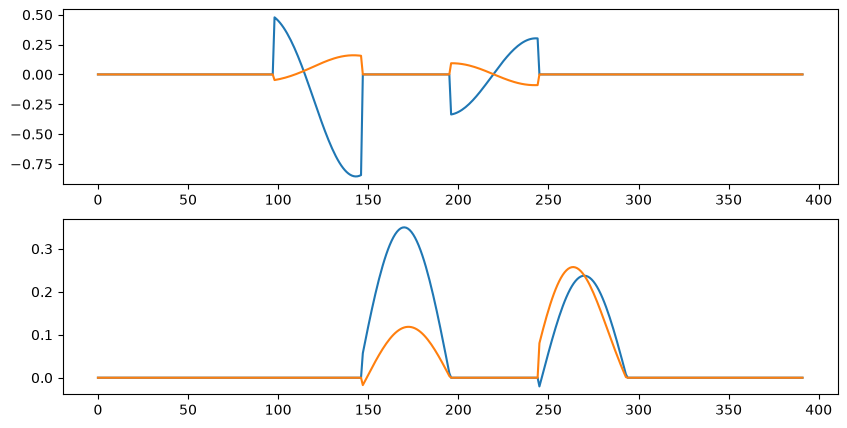

In [188]:
cmds = np.hstack([
    np.zeros((49)),
    np.zeros((49)),
    sol_rev_1s["stance_control"],
    np.zeros((49)),
    sol_bac_1s["stance_control"],
    np.zeros((49)),
    np.zeros((49)),
    np.zeros((49)),
])
cmdf = np.hstack([
    np.zeros((49)),
    np.zeros((49)),
    np.zeros((49)),
    sol_rev_1s["flight_control"],
    np.zeros((49)),
    sol_bac_1s["flight_control"],
    np.zeros((49)),
    np.zeros((49)),
])
cmds_baseline = np.hstack([
    np.zeros((49)),
    np.zeros((49)),
    sol_baseline["stance_control"][0],
    np.zeros((49)),
    sol_baseline["stance_control"][1],
    np.zeros((49)),
    np.zeros((49)),
    np.zeros((49)),
])
cmdf_baseline = np.hstack([
    np.zeros((49)),
    np.zeros((49)),
    np.zeros((49)),
    sol_baseline["flight_control"][0],
    np.zeros((49)),
    sol_baseline["flight_control"][1],
    np.zeros((49)),
    np.zeros((49)),
])


fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(2,1,1)
ax1.plot(cmds)
ax1.plot(cmds_baseline)
ax2 = fig.add_subplot(2,1,2)
ax2.plot(cmdf)
ax2.plot(cmdf_baseline)
plt.show()

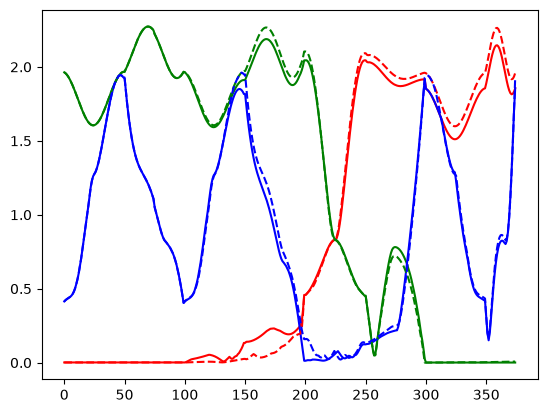

In [242]:

surface_FW,_ = get_surface(1000,FW,S_bac_1s)
surface_BW,_ = get_surface(1000,BW,S_bac_1s)
surface_FW_TO_BW,_ = get_surface(1000,FW_TO_BW,S_bac_1s)
dist_FW = []
dist_BW = []
dist_FW_TO_BW = []
for i in range(traj.shape[1]):
    dist_FW.append(np.min(np.linalg.norm(surface_FW[:,1:5,:] - traj[1:5,i][None,:,None],axis=1)))
    dist_BW.append(np.min(np.linalg.norm(surface_BW[:,1:5,:] - traj[1:5,i][None,:,None],axis=1)))
    dist_FW_TO_BW.append(np.min(np.linalg.norm(surface_FW_TO_BW[:,1:5,:] - traj[1:5,i][None,:,None],axis=1)))

dist_FW_baseline = []
dist_BW_baseline = []
dist_FW_TO_BW_baseline = []
for i in range(traj.shape[1]):
    dist_FW_baseline.append(np.min(np.linalg.norm(surface_FW[:,1:5,:] - traj_baseline[1:5,i][None,:,None],axis=1)))
    dist_BW_baseline.append(np.min(np.linalg.norm(surface_BW[:,1:5,:] - traj_baseline[1:5,i][None,:,None],axis=1)))
    dist_FW_TO_BW_baseline.append(np.min(np.linalg.norm(surface_FW_TO_BW[:,1:5,:] - traj_baseline[1:5,i][None,:,None],axis=1)))

plt.plot(dist_FW,'red')
plt.plot(dist_BW,'green')
plt.plot(dist_FW_TO_BW,'blue')
plt.plot(dist_FW_baseline,'red',linestyle='--')
plt.plot(dist_BW_baseline,'green',linestyle='--')
plt.plot(dist_FW_TO_BW_baseline,'blue',linestyle='--')


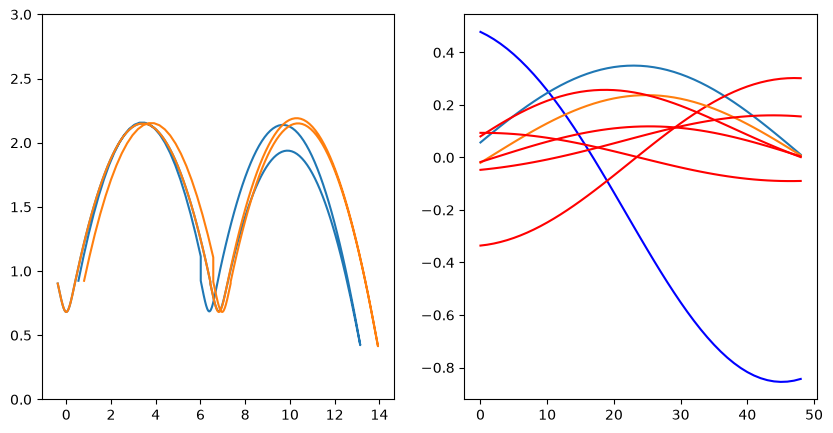

In [106]:


plt.figure(figsize=(10,5))
plt.subplot(1,2,2)
# for us in sol_step1["stance_control"]:
#     plt.plot(us,color='blue')
# for uf in sol_step1["flight_control"]:
#     plt.plot(uf,color='blue')

plt.plot(sol_rev_1s["stance_control"],color='blue')
plt.plot(sol_rev_1s["flight_control"])

plt.plot(sol_bac_1s["stance_control"],color='red')
plt.plot(sol_bac_1s["flight_control"])
for us in sol_baseline["stance_control"]:
    plt.plot(us,color='red')
for uf in sol_baseline["flight_control"]:
    plt.plot(uf,color='red')

plt.subplot(1,2,1)
plt.ylim(0,3)
plt.plot(traj[0,:],traj[1,:])
plt.plot(traj_baseline[0,:],traj_baseline[1,:])
# for traj_baseline in sol_baseline['flight']:
#     plt.plot(traj_baseline[0,:],traj_baseline[1,:])
# for traj_baseline in sol_baseline['stance']:
#     plt.plot(traj_baseline[0,:],traj_baseline[1,:])
# plt.plot(sol_rev_1s["stance"][0,:],sol_rev_1s["stance"][1,:])
# plt.plot(sol_rev_1s["flight"][0,:],sol_rev_1s["flight"][1,:])
# plt.plot(sol_bac_1s["stance"][0,:],sol_bac_1s["stance"][1,:])
# plt.plot(sol_bac_1s["flight"][0,:],sol_bac_1s["flight"][1,:])
# plt.plot(passive_traj[0,:].T,passive_traj[1,:].T)
# plt.plot(xs_init[0,:],xs_init[1,:])
# plt.plot(xf_init[0,:],xf_init[1,:])
# plt.plot(fw_to_bw[0,:],fw_to_bw[1,:])
# plt.plot(bw[0,:],bw[1,:])

plt.show()

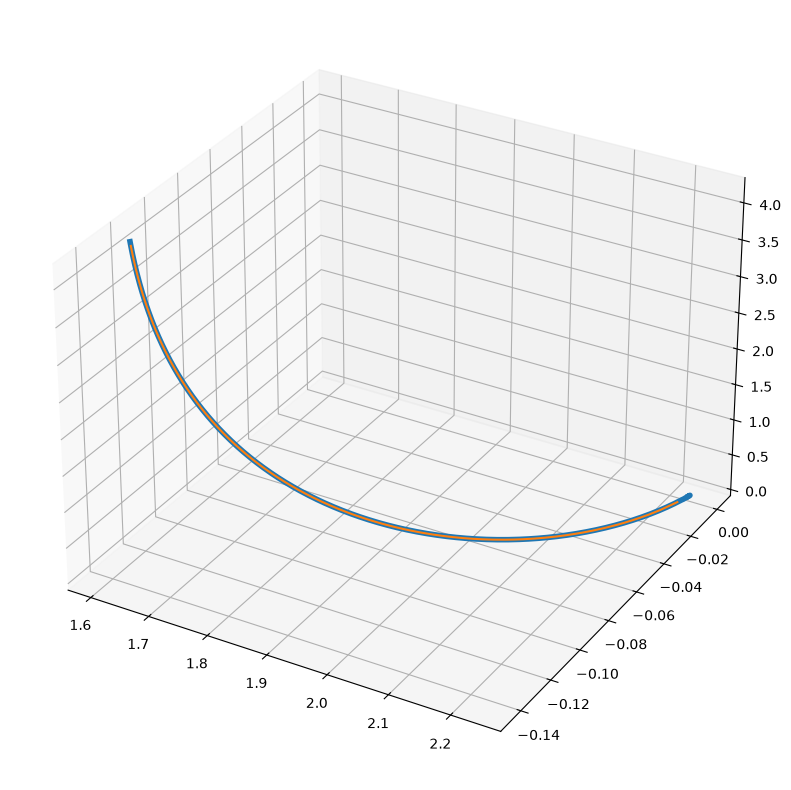

In [107]:
E_grid = np.linspace(Emin_FW_TO_BW,Emax_FW_TO_BW,1000).reshape((-1,))
BW_TO_FWi = np.zeros((1000,11))
for i in range(1000):
    BW_TO_FWi[i,:] = np.array(LUT_FW_TO_BW(E_grid[i])).reshape((-1,))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1,projection='3d')
ax.plot(FW_TO_BW[:,1],FW_TO_BW[:,2],FW_TO_BW[:,3],linewidth=4)
ax.plot(BW_TO_FWi[:,1],BW_TO_FWi[:,2],BW_TO_FWi[:,3])


In [108]:
# # warm start reversing

# theta_TD = fw[2,-1]
# theta_star = cs.atan2(-fw[3,0],fw[4,0]) + cs.pi
# print(theta_TD,theta_star)
# delta_theta = theta_star - theta_TD

# T = u_fw[6]*50
# t = cs.linspace(0,T,50)
# D = T / (2*W**2) - cs.sin(2*W*T) / (4*W**3)

# uf_guess = delta_theta / D * cs.sin(W*(T-t)) / W
# theta_t = fw[2,50:] + delta_theta / (2*W**2*D) * (t*cs.cos(W*(T-t)) - cs.cos(W*T)/W * cs.sin(W*t))
# dtheta_t = fw[5,50:] +  theta_TD + delta_theta / (2*W**2*D) * (cs.cos(W*(T-t)) + W*t*cs.sin(W*(T-t)) - cs.cos(W*T)*cs.cos(W*t))

# actuated_flight = cs.vertcat(fw[:2,50:],theta_t.T,fw[3:5,50:],dtheta_t.T)

# print(actuated_flight[3,-1]*cs.cos(actuated_flight[2,-1])+actuated_flight[4,-1]*cs.sin(actuated_flight[2,-1]))

# step2s_guess = S_bac_2s.traj_s_list(S_bac_2s.flight_to_stance(actuated_flight[:,-1]),u_fw[7],0)
# step2f_guess = S_bac_2s.traj_f_list(S_bac_2s.stance_to_flight(step2s_guess[:,-1]),0.9*u_fw[6]*2,0)
# plt.plot(fw[0,:50],fw[1,:50])
# plt.plot(actuated_flight[0,:].T,actuated_flight[1,:].T)
# plt.plot(step2s_guess[0,:].T,step2s_guess[1,:].T)
# plt.plot(step2f_guess[0,:].T,step2f_guess[1,:].T)

In [109]:
# ## first step with S_rev_2s

# x0 = fw[[0,1,3,4],0]
# xs_init = [fw[[0,1,3,4],:S_rev_2s.N],fw_to_bw[[0,1,3,4],:S_rev_2s.N]]
# xf_init = [fw[:,S_rev_2s.N:],fw_to_bw[:,S_rev_2s.N:]]
# dt_init = cs.vertcat(u_fw[6]+u_fw[8],u_fw[7],u_fw[6]+u_fw[8],u_fw[7])
# S_rev_2s.initialize(x0,xs_init,xf_init,dt_init,[0,0],[uf_guess[:-1],0])
# start = time()
# sol_step1 = S_rev_2s.solve()
# end = time()
# print(end-start)

In [110]:
# # second step with S_bac_2s

# x0 = sol_step1["stance"][1][:,0]
# xs_init = [fw_to_bw[[0,1,3,4],:S_rev_2s.N],bw[[0,1,3,4],:S_rev_2s.N]]
# xf_init = [fw_to_bw[:,S_rev_2s.N:],bw[:,S_rev_2s.N:]]
# dt_init = cs.vertcat(u_fw_to_bw[6]+u_fw_to_bw[8],u_fw_to_bw[7],u_bw[6]+u_bw[8],u_bw[7])
# S_bac_2s.initialize(x0,xs_init,xf_init,dt_init)
# start = time()
# sol_step2 = S_bac_2s.solve()
# end = time()
# print(end-start)
